<a href="https://colab.research.google.com/github/Jee8825/AMD-Slingshot-MVP/blob/main/Day_3/Day_3_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
API_key= "9dff3cdbc04d70fc3d238528c3aabc2d"
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai','Delhi','Coimbatore','Chennai','Madurai','Pune','Salem','Sivakasi','Erode','London']

In [15]:
import requests

def fetch_weather(city,api_key):
    params={
        'q':city,
        'appid':api_key,
        'units':'metric'
    }
    response=requests.get(BASE_URL,params=params)
    return response.json()
weather_records=[]
for city in CITIES:
    print(f'Fecthing: {city}...',end='')
    record=fetch_weather(city,API_key)
    print('Done')
    weather_records.append(record)
    print(f"{record['main']['temp']}ºC, Feels like: {record['main']['feels_like']}ºC, Humidity: {record['main']['humidity']}%, Pressure: {record['main']['pressure']}hPa, {record['weather'][0]['description']}")

Fecthing: Mumbai...Done
33.99ºC, Feels like: 40.99ºC, Humidity: 59%, Pressure: 1009hPa, haze
Fecthing: Delhi...Done
44.05ºC, Feels like: 41.11ºC, Humidity: 10%, Pressure: 999hPa, clear sky
Fecthing: Coimbatore...Done
33.88ºC, Feels like: 38.81ºC, Humidity: 52%, Pressure: 1008hPa, scattered clouds
Fecthing: Chennai...Done
35.91ºC, Feels like: 42.91ºC, Humidity: 54%, Pressure: 1005hPa, few clouds
Fecthing: Madurai...Done
38.01ºC, Feels like: 45.01ºC, Humidity: 44%, Pressure: 1006hPa, scattered clouds
Fecthing: Pune...Done
36.34ºC, Feels like: 35.73ºC, Humidity: 26%, Pressure: 1008hPa, overcast clouds
Fecthing: Salem...Done
37.53ºC, Feels like: 44.53ºC, Humidity: 51%, Pressure: 1007hPa, broken clouds
Fecthing: Sivakasi...Done
38.23ºC, Feels like: 40.57ºC, Humidity: 32%, Pressure: 1006hPa, overcast clouds
Fecthing: Erode...Done
35.2ºC, Feels like: 35.9ºC, Humidity: 34%, Pressure: 1006hPa, overcast clouds
Fecthing: London...Done
24.33ºC, Feels like: 24.28ºC, Humidity: 56%, Pressure: 1024hPa

In [16]:
import pandas as pd

df_weather = pd.DataFrame(weather_records)
display(df_weather.head())

,coord,weather,base,main,visibility,wind,clouds,dt,sys,timezone,id,name,cod
0,"{'lon': 72.8479, 'lat': 19.0144}","[{'id': 721, 'main': 'Haze', 'description': 'h...",stations,"{'temp': 33.99, 'feels_like': 40.99, 'temp_min...",7000,"{'speed': 6.17, 'deg': 270}",{'all': 40},1779875937,"{'type': 1, 'id': 9052, 'country': 'IN', 'sunr...",19800,1275339,Mumbai,200
1,"{'lon': 77.2167, 'lat': 28.6667}","[{'id': 800, 'main': 'Clear', 'description': '...",stations,"{'temp': 44.05, 'feels_like': 41.11, 'temp_min...",7000,"{'speed': 5.14, 'deg': 300, 'gust': 10.29}",{'all': 0},1779875876,"{'type': 1, 'id': 9165, 'country': 'IN', 'sunr...",19800,1273294,Delhi,200
2,"{'lon': 76.9667, 'lat': 11}","[{'id': 802, 'main': 'Clouds', 'description': ...",stations,"{'temp': 33.88, 'feels_like': 38.81, 'temp_min...",7000,"{'speed': 6.17, 'deg': 200}",{'all': 40},1779876466,"{'type': 1, 'id': 9206, 'country': 'IN', 'sunr...",19800,1273865,Coimbatore,200
3,"{'lon': 80.2785, 'lat': 13.0878}","[{'id': 801, 'main': 'Clouds', 'description': ...",stations,"{'temp': 35.91, 'feels_like': 42.91, 'temp_min...",6000,"{'speed': 5.14, 'deg': 120}",{'all': 20},1779876252,"{'type': 2, 'id': 2093935, 'country': 'IN', 's...",19800,1264527,Chennai,200
4,"{'lon': 78.1167, 'lat': 9.9333}","[{'id': 802, 'main': 'Clouds', 'description': ...",stations,"{'temp': 38.01, 'feels_like': 45.01, 'temp_min...",6000,"{'speed': 1.03, 'deg': 0}",{'all': 40},1779876531,"{'type': 1, 'id': 9216, 'country': 'IN', 'sunr...",19800,1264521,Madurai,200


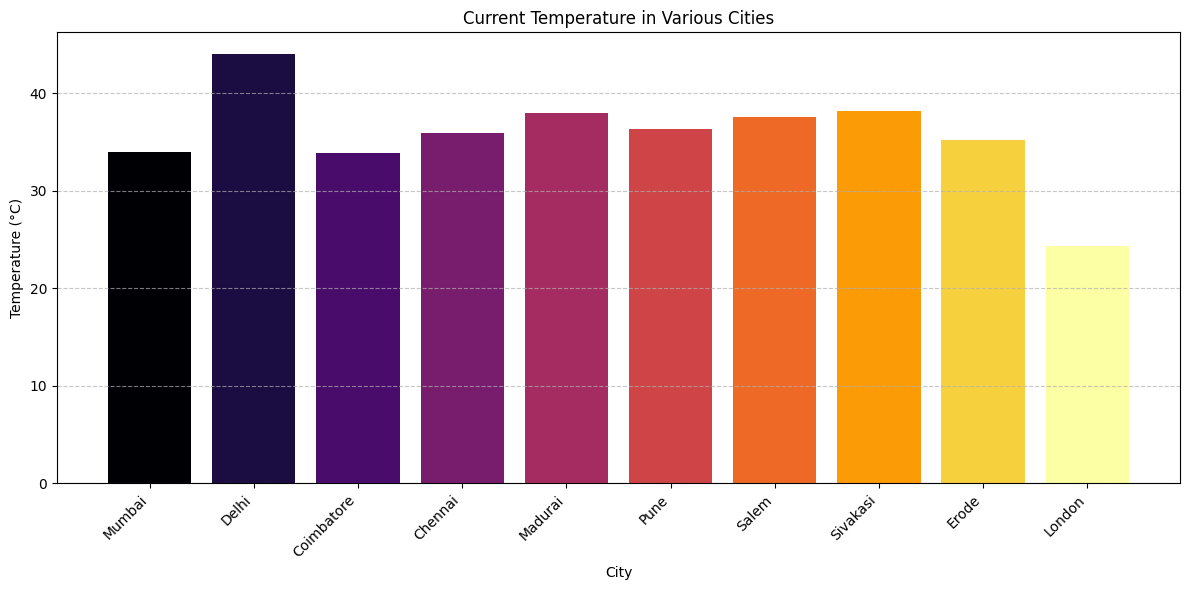

In [25]:
import matplotlib.pyplot as plt

# e.g., 'plasma', 'inferno', 'magma', 'cividis', 'tab10', etc.
cmap_name = 'inferno'

cmap = plt.get_cmap(cmap_name)
colors = cmap(df_weather_flat['city_name'].index / float(len(df_weather_flat['city_name']) - 1))

plt.figure(figsize=(12, 6))
plt.bar(df_weather_flat['city_name'], df_weather_flat['temperature_celsius'], color=colors)
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.title('Current Temperature in Various Cities')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
weather_data_flattened = []

for index, row in df_weather.iterrows():
    city_data = {
        'city_name': row['name'],
        'latitude': row['coord']['lat'],
        'longitude': row['coord']['lon'],
        'temperature_celsius': row['main']['temp'],
        'feels_like_celsius': row['main']['feels_like'],
        'humidity_percent': row['main']['humidity'],
        'pressure_hPa': row['main']['pressure'],
        'weather_description': row['weather'][0]['description']
    }
    weather_data_flattened.append(city_data)

df_weather_flat = pd.DataFrame(weather_data_flattened)
display(df_weather_flat.head(10))

,city_name,latitude,longitude,temperature_celsius,feels_like_celsius,humidity_percent,pressure_hPa,weather_description
0,Mumbai,19.0144,72.8479,33.99,40.99,59,1009,haze
1,Delhi,28.6667,77.2167,44.05,41.11,10,999,clear sky
2,Coimbatore,11.0000,76.9667,33.88,38.81,52,1008,scattered clouds
3,Chennai,13.0878,80.2785,35.91,42.91,54,1005,few clouds
4,Madurai,9.9333,78.1167,38.01,45.01,44,1006,scattered clouds
5,Pune,18.5196,73.8553,36.34,35.73,26,1008,overcast clouds
6,Salem,11.6500,78.1667,37.53,44.53,51,1007,broken clouds
7,Sivakasi,9.4500,77.8167,38.23,40.57,32,1006,overcast clouds
8,Erode,11.3500,77.7333,35.20,35.90,34,1006,overcast clouds
9,London,51.5085,-0.1257,24.33,24.28,56,1024,clear sky
